In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully")

In [ ]:
df = pd.read_csv(r'C:\Users\vvlal\OneDrive\Desktop\AML Project\Kaggledataset.csv')

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)



In [6]:
# Check fraud count
print("=== FRAUD vs NOT FRAUD ===")
print(df['isFraud'].value_counts())
print(f"Fraud rate: {df['isFraud'].mean()*100:.4f}%")

print("\n=== TRANSACTION TYPES ===")
print(df['type'].value_counts())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATS ===")
print(df[['amount','oldbalanceOrg','newbalanceOrig']].describe())

=== FRAUD vs NOT FRAUD ===
isFraud
0    1047433
1       1142
Name: count, dtype: int64
Fraud rate: 0.1089%

=== TRANSACTION TYPES ===
type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

=== MISSING VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== BASIC STATS ===
             amount  oldbalanceOrg  newbalanceOrig
count  1.048575e+06   1.048575e+06    1.048575e+06
mean   1.586670e+05   8.740095e+05    8.938089e+05
std    2.649409e+05   2.971751e+06    3.008271e+06
min    1.000000e-01   0.000000e+00    0.000000e+00
25%    1.214907e+04   0.000000e+00    0.000000e+00
50%    7.634333e+04   1.600200e+04    0.000000e+00
75%    2.137619e+05   1.366420e+05    1.746000e+05
max    1.000000e+07   3.890000e+07    3.890000e+07


In [7]:
# Create new columns that represent AML red flags

# Hour of day (step = hour number, convert to 0-23 cycle)
df['hour_of_day'] = df['step'] % 24

# Round number flag (AML red flag — structuring indicator)
df['is_round_number'] = (df['amount'] % 1000 == 0).astype(int)

# Balance drain to zero (sender account emptied completely)
df['balance_drain'] = (
    (df['oldbalanceOrg'] > 0) & 
    (df['newbalanceOrig'] == 0)
).astype(int)

# Balance change amount
df['balance_change_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# Verify new columns
print("=== NEW FEATURES CREATED ===")
print(f"Round number transactions: {df['is_round_number'].sum():,}")
print(f"Balance drain transactions: {df['balance_drain'].sum():,}")
print(f"\nFraud rate in balance drains: {df[df['balance_drain']==1]['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate in round numbers: {df[df['is_round_number']==1]['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate overall:          {df['isFraud'].mean()*100:.4f}%")
print("\nSample of new columns:")
df[['amount','is_round_number','hour_of_day','balance_drain','balance_change_orig']].head(5)


=== NEW FEATURES CREATED ===
Round number transactions: 24
Balance drain transactions: 240,972

Fraud rate in balance drains: 0.46%
Fraud rate in round numbers: 58.33%
Fraud rate overall:          0.1089%

Sample of new columns:


,amount,is_round_number,hour_of_day,balance_drain,balance_change_orig
0,9839.64,0,1,0,9839.64
1,1864.28,0,1,0,1864.28
2,181.00,0,1,1,181.00
3,181.00,0,1,1,181.00
4,11668.14,0,1,0,11668.14


In [8]:
# Load data into SQLite for SQL analysis
conn = sqlite3.connect(':memory:')
df.to_sql('transactions', conn, index=False, if_exists='replace')
print("Data loaded into SQL database successfully")

# QUERY 1: Fraud by transaction type
q1 = """
SELECT 
    type,
    COUNT(*) as total_count,
    SUM(isFraud) as fraud_count,
    ROUND(100.0 * SUM(isFraud) / COUNT(*), 4) as fraud_rate_pct,
    ROUND(AVG(amount), 2) as avg_amount
FROM transactions
GROUP BY type
ORDER BY fraud_count DESC
"""
result1 = pd.read_sql_query(q1, conn)
print("\n=== QUERY 1: Fraud by Transaction Type ===")
print(result1.to_string(index=False))

# QUERY 2: Round number analysis
q2 = """
SELECT 
    is_round_number,
    COUNT(*) as count,
    SUM(isFraud) as fraud_count,
    ROUND(100.0 * SUM(isFraud) / COUNT(*), 4) as fraud_rate_pct
FROM transactions
GROUP BY is_round_number
"""
result2 = pd.read_sql_query(q2, conn)
print("\n=== QUERY 2: Round Number vs Fraud ===")
print(result2.to_string(index=False))

# QUERY 3: Balance drain analysis
q3 = """
SELECT 
    type,
    COUNT(*) as drain_count,
    SUM(isFraud) as fraud_count,
    ROUND(100.0 * SUM(isFraud) / COUNT(*), 4) as fraud_rate_pct,
    ROUND(AVG(amount), 2) as avg_drain_amount
FROM transactions
WHERE balance_drain = 1
GROUP BY type
ORDER BY fraud_count DESC
"""
result3 = pd.read_sql_query(q3, conn)
print("\n=== QUERY 3: Balance Drain by Type ===")
print(result3.to_string(index=False))

# QUERY 4: Window function — running fraud total by hour
q4 = """
SELECT
    hour_of_day,
    COUNT(*) as total_transactions,
    SUM(isFraud) as fraud_count,
    ROUND(100.0 * SUM(isFraud) / COUNT(*), 4) as fraud_rate_pct,
    SUM(SUM(isFraud)) OVER (ORDER BY hour_of_day) as running_fraud_total
FROM transactions
GROUP BY hour_of_day
ORDER BY hour_of_day
"""
result4 = pd.read_sql_query(q4, conn)
print("\n=== QUERY 4: Hourly Pattern with Running Total (WINDOW FUNCTION) ===")
print(result4.to_string(index=False))

# QUERY 5: High value transactions above average
q5 = """
SELECT 
    type,
    COUNT(*) as high_value_count,
    SUM(isFraud) as fraud_count,
    ROUND(100.0 * SUM(isFraud) / COUNT(*), 4) as fraud_rate_pct,
    ROUND(AVG(amount), 2) as avg_amount
FROM transactions
WHERE amount > 200000
GROUP BY type
ORDER BY fraud_count DESC
"""
result5 = pd.read_sql_query(q5, conn)
print("\n=== QUERY 5: High Value Transactions (>200,000) ===")
print(result5.to_string(index=False))

Data loaded into SQL database successfully

=== QUERY 1: Fraud by Transaction Type ===
    type  total_count  fraud_count  fraud_rate_pct  avg_amount
CASH_OUT       373641          578          0.1547   184039.59
TRANSFER        86753          564          0.6501   634403.83
 PAYMENT       353873            0          0.0000    11122.91
   DEBIT         7178            0          0.0000     5878.52
 CASH_IN       227130            0          0.0000   169923.65

=== QUERY 2: Round Number vs Fraud ===
 is_round_number   count  fraud_count  fraud_rate_pct
               0 1048551         1128          0.1076
               1      24           14         58.3333

=== QUERY 3: Balance Drain by Type ===
    type  drain_count  fraud_count  fraud_rate_pct  avg_drain_amount
CASH_OUT       155237          561          0.3614         218530.93
TRANSFER        37621          552          1.4673         735213.35
 PAYMENT        47166            0          0.0000          15955.62
   DEBIT         

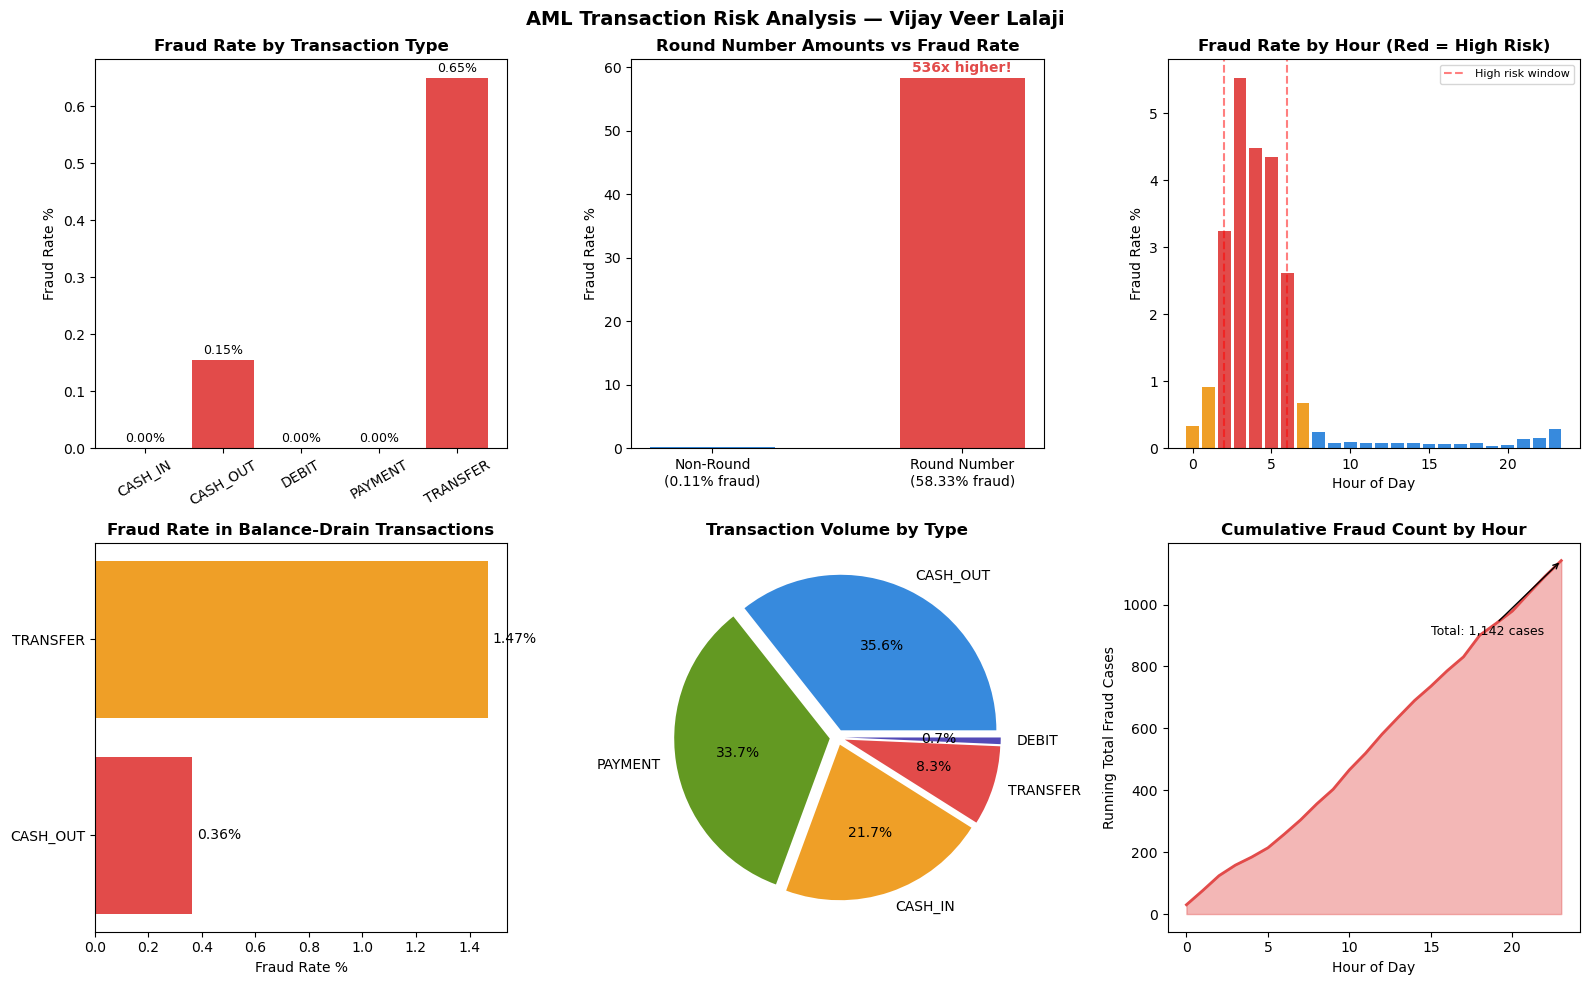

Charts saved to: C:\Users\vvlal\OneDrive\Desktop\AML Project\charts.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('AML Transaction Risk Analysis — Vijay Veer Lalaji', 
             fontsize=14, fontweight='bold')

# Chart 1: Fraud rate by transaction type
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum','mean']).reset_index()
fraud_by_type.columns = ['type','fraud_count','fraud_rate']
axes[0,0].bar(fraud_by_type['type'], fraud_by_type['fraud_rate']*100, 
              color=['#E24B4A' if x > 0 else '#378ADD' for x in fraud_by_type['fraud_rate']])
axes[0,0].set_title('Fraud Rate by Transaction Type', fontweight='bold')
axes[0,0].set_ylabel('Fraud Rate %')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(fraud_by_type['fraud_rate']*100):
    axes[0,0].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9)

# Chart 2: Round number vs fraud
categories = ['Non-Round\n(0.11% fraud)', 'Round Number\n(58.33% fraud)']
values = [0.1076, 58.3333]
colors = ['#378ADD', '#E24B4A']
bars = axes[0,1].bar(categories, values, color=colors, width=0.5)
axes[0,1].set_title('Round Number Amounts vs Fraud Rate', fontweight='bold')
axes[0,1].set_ylabel('Fraud Rate %')
axes[0,1].text(1, 58.3333 + 1, '536x higher!', ha='center', 
               fontsize=10, color='#E24B4A', fontweight='bold')

# Chart 3: Hourly fraud rate
hours = result4['hour_of_day']
fraud_rates = result4['fraud_rate_pct']
colors_hour = ['#E24B4A' if x > 1 else '#EF9F27' if x > 0.3 else '#378ADD' 
               for x in fraud_rates]
axes[0,2].bar(hours, fraud_rates, color=colors_hour)
axes[0,2].set_title('Fraud Rate by Hour (Red = High Risk)', fontweight='bold')
axes[0,2].set_xlabel('Hour of Day')
axes[0,2].set_ylabel('Fraud Rate %')
axes[0,2].axvline(x=2, color='red', linestyle='--', alpha=0.5, label='High risk window')
axes[0,2].axvline(x=6, color='red', linestyle='--', alpha=0.5)
axes[0,2].legend(fontsize=8)

# Chart 4: Balance drain fraud rate by type
drain_data = result3[result3['fraud_count'] > 0]
axes[1,0].barh(drain_data['type'], drain_data['fraud_rate_pct'], 
               color=['#E24B4A', '#EF9F27'])
axes[1,0].set_title('Fraud Rate in Balance-Drain Transactions', fontweight='bold')
axes[1,0].set_xlabel('Fraud Rate %')
for i, v in enumerate(drain_data['fraud_rate_pct']):
    axes[1,0].text(v + 0.02, i, f'{v:.2f}%', va='center', fontsize=10)

# Chart 5: Transaction volume by type (pie)
type_counts = df['type'].value_counts()
explode = [0.05] * len(type_counts)
axes[1,1].pie(type_counts.values, labels=type_counts.index, 
              autopct='%1.1f%%', explode=explode,
              colors=['#378ADD','#639922','#EF9F27','#E24B4A','#534AB7'])
axes[1,1].set_title('Transaction Volume by Type', fontweight='bold')

# Chart 6: Running fraud total by hour
axes[1,2].fill_between(result4['hour_of_day'], result4['running_fraud_total'], 
                        alpha=0.4, color='#E24B4A')
axes[1,2].plot(result4['hour_of_day'], result4['running_fraud_total'], 
               color='#E24B4A', linewidth=2)
axes[1,2].set_title('Cumulative Fraud Count by Hour', fontweight='bold')
axes[1,2].set_xlabel('Hour of Day')
axes[1,2].set_ylabel('Running Total Fraud Cases')
axes[1,2].annotate(f'Total: 1,142 cases', xy=(23, 1142), 
                   xytext=(15, 900), fontsize=9,
                   arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
save_path = r'C:\Users\vvlal\OneDrive\Desktop\AML Project\charts.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Charts saved to: {save_path}")


In [10]:
# Encode transaction type (convert text to numbers)
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

# Select features
features = ['type_encoded', 'amount', 'balance_change_orig', 
            'balance_drain', 'is_round_number', 'hour_of_day']

X = df[features]
y = df['isFraud']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")

# Train model
print("Training model... (takes 30-60 seconds)")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully")

# Evaluate
y_pred = model.predict(X_test)
print("\n=== MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred, 
      target_names=['Legitimate', 'Fraud']))

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=False)
print("=== WHICH FEATURES PREDICT FRAUD BEST ===")
print(feature_importance.to_string(index=False))

Training rows: 838,860  |  Test rows: 209,715
Training model... (takes 30-60 seconds)
Model trained successfully

=== MODEL PERFORMANCE ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    209491
       Fraud       0.62      0.31      0.42       224

    accuracy                           1.00    209715
   macro avg       0.81      0.66      0.71    209715
weighted avg       1.00      1.00      1.00    209715

=== WHICH FEATURES PREDICT FRAUD BEST ===
            Feature  Importance
        hour_of_day    0.531439
       type_encoded    0.096993
      balance_drain    0.000451
balance_change_orig    0.000098
             amount    0.000093
    is_round_number    0.000005


In [11]:
# Export 1: Flagged transactions only
flagged = df[df['isFraud'] == 1].copy()
flagged.to_csv(
    r'C:\Users\vvlal\OneDrive\Desktop\AML Project\flagged_transactions.csv', 
    index=False
)

# Export 2: Sample for Power BI (100K rows)
df_sample = df.sample(n=100000, random_state=42)
df_sample.to_csv(
    r'C:\Users\vvlal\OneDrive\Desktop\AML Project\transactions_sample.csv', 
    index=False
)

# Export 3: Summary by type and hour
summary = df.groupby(['type', 'hour_of_day']).agg(
    total_transactions=('amount', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    fraud_count=('isFraud', 'sum'),
    fraud_rate=('isFraud', 'mean')
).reset_index()
summary.to_csv(
    r'C:\Users\vvlal\OneDrive\Desktop\AML Project\summary_by_type_hour.csv', 
    index=False
)

# Export 4: SQL query results for Excel
result1.to_csv(
    r'C:\Users\vvlal\OneDrive\Desktop\AML Project\sql_fraud_by_type.csv', 
    index=False
)
result4.to_csv(
    r'C:\Users\vvlal\OneDrive\Desktop\AML Project\sql_hourly_pattern.csv', 
    index=False
)

print("=== FILES EXPORTED ===")
print(f"flagged_transactions.csv     — {len(flagged):,} fraud cases")
print(f"transactions_sample.csv      — {len(df_sample):,} rows for Power BI")
print(f"summary_by_type_hour.csv     — {len(summary):,} summary rows")
print(f"sql_fraud_by_type.csv        — {len(result1)} rows")
print(f"sql_hourly_pattern.csv       — {len(result4)} rows")
print("\nDay 1 complete. All files saved to AML Project folder.")

=== FILES EXPORTED ===
flagged_transactions.csv     — 1,142 fraud cases
transactions_sample.csv      — 100,000 rows for Power BI
summary_by_type_hour.csv     — 120 summary rows
sql_fraud_by_type.csv        — 5 rows
sql_hourly_pattern.csv       — 24 rows

Day 1 complete. All files saved to AML Project folder.


In [12]:
# Re-export flagged transactions WITH all engineered columns
flagged = df[df['isFraud'] == 1][['step', 'type', 'amount', 'nameOrig', 
                                   'oldbalanceOrg', 'newbalanceOrig',
                                   'nameDest', 'oldbalanceDest', 'newbalanceDest',
                                   'isFraud', 'hour_of_day', 'is_round_number', 
                                   'balance_drain', 'balance_change_orig']].copy()

flagged.to_csv(
    r'C:\Users\vvlal\OneDrive\Desktop\AML Project\flagged_transactions.csv', 
    index=False
)
print(f"Re-exported with all columns: {flagged.columns.tolist()}")
print(f"Rows: {len(flagged)}")

Re-exported with all columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'hour_of_day', 'is_round_number', 'balance_drain', 'balance_change_orig']
Rows: 1142


In [13]:
# Check exact column names in the dataframe
print(df.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'hour_of_day', 'is_round_number', 'balance_drain', 'balance_change_orig', 'type_encoded']


In [14]:
flagged = df[df['isFraud'] == 1][['step', 'type', 'amount', 'nameOrig', 
                                   'oldbalanceOrg', 'newbalanceOrig',
                                   'nameDest', 'oldbalanceDest', 'newbalanceDest',
                                   'isFraud', 'isFlaggedFraud', 'hour_of_day', 
                                   'is_round_number', 'balance_drain', 
                                   'balance_change_orig']].copy()

flagged.to_csv(
    r'C:\Users\vvlal\OneDrive\Desktop\AML Project\flagged_transactions.csv', 
    index=False
)
print("Done:", flagged.columns.tolist())

Done: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'hour_of_day', 'is_round_number', 'balance_drain', 'balance_change_orig']


In [15]:
df.to_csv(
    r'C:\Users\vvlal\OneDrive\Desktop\AML Project\transactions_full.csv',
    index=False
)
print(f"Exported: {len(df):,} rows")

Exported: 1,048,575 rows
